# Feature Importance Study

This notebook performs a comprehensive feature importance study on the XGBoost model trained on 78-dimensional engineered features.

## Sections:
1. **Setup & Data Loading** - Load model, data, and reconstruct test features
2. **Native XGBoost Importance** - Study gain, weight, and cover importance types
3. **Matplotlib Visualization** - Visualize importance with custom plots
4. **LIME-based Importance** - Local Interpretable Model-agnostic Explanations
5. **SHAP-based Importance** - SHapley Additive exPlanations
6. **Permutation Feature Importance** - Three options (Full, Prefiltered, Configurable)

---

## Section 0: Setup & Imports

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

import sys
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model.xgboost_model import EngagementXGBoost
from src.feature_engineering import FeatureEngineer, engineer_dataset_features
from src.normalization.feature_normalization import FeatureNormalizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb

In [14]:
# Constants
AFFECTIVE_STATES = ["boredom", "engagement", "confusion", "frustration"]
CLASS_NAMES = ["Low", "Medium", "High"]

# Paths
PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "outputs_v2" / "xgboost" / "latest"
DATA_DIR = PROJECT_ROOT / "daisee_features_v2"
CHECKPOINT_PATH = OUTPUT_DIR / "checkpoints" / "final_model.pt"
NORMALIZER_PATH = OUTPUT_DIR / "checkpoints" / "normalizer.pkl"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Project root: ..
Output dir: ../outputs_v2/xgboost/latest
Checkpoint: ../outputs_v2/xgboost/latest/checkpoints/final_model.pt


---

## Section 1: Load Model, Data, and Reconstruct Test Set

In [15]:
# Load the dataset
print("Loading dataset...")
with open(DATA_DIR / "complete_dataset.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]  # (N, 150, 78)
y = data["y"]  # dict of labels per state
feature_names = data.get("feature_names", [f"feature_{i}" for i in range(78)])

print(f"X shape: {X.shape}")
print(f"Feature names: {len(feature_names)} features")
print(f"Label keys: {list(y.keys())}")

Loading dataset...
X shape: (8503, 150, 78)
Feature names: 78 features
Label keys: ['boredom', 'engagement', 'confusion', 'frustration']


In [16]:
# Replicate the same split (seed=42, 70/15/15)
print("\nReplicating train/val/test split...")
cfg = {
    "data": {
        "train_ratio": 0.70,
        "val_ratio": 0.15,
        "test_ratio": 0.15,
        "random_seed": 42
    }
}

seed = cfg["data"]["random_seed"]
train_ratio = cfg["data"]["train_ratio"]
val_ratio = cfg["data"]["val_ratio"]
test_ratio = cfg["data"]["test_ratio"]

n_samples = X.shape[0]
indices = np.arange(n_samples)
np.random.seed(seed)
np.random.shuffle(indices)

train_end = int(n_samples * train_ratio)
val_end = int(n_samples * (train_ratio + val_ratio))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train = {s: y[s][train_idx] for s in AFFECTIVE_STATES}
y_val = {s: y[s][val_idx] for s in AFFECTIVE_STATES}
y_test = {s: y[s][test_idx] for s in AFFECTIVE_STATES}

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Replicating train/val/test split...
Train: 5952, Val: 1275, Test: 1276


In [18]:
# Load normalizer and apply to test set
print("\nLoading normalizer and applying to test set...")
with open(NORMALIZER_PATH, "rb") as f:
    normalizer = pickle.load(f)

# normalizer.pkl may contain either a FeatureNormalizer object or a serialized dict
if hasattr(normalizer, "transform"):
    X_test = normalizer.transform(X_test)
elif isinstance(normalizer, dict) and "scalers" in normalizer and "feature_groups" in normalizer:
    X_test_norm = X_test.copy()
    name_to_idx = {name: i for i, name in enumerate(normalizer["feature_names"])}
    X_flat = X_test_norm.reshape(-1, X_test_norm.shape[-1])  # (N*T, F)

    for group_name, group_features in normalizer["feature_groups"].items():
        scaler = normalizer["scalers"].get(group_name)
        if scaler is None:
            continue

        # feature groups are expected to be feature names
        group_idx = [name_to_idx[f] for f in group_features if f in name_to_idx]
        if not group_idx:
            continue

        X_flat[:, group_idx] = scaler.transform(X_flat[:, group_idx])

    X_test = X_flat.reshape(X_test_norm.shape).astype(np.float32)
else:
    raise TypeError(
        f"Unsupported normalizer type: {type(normalizer)}. "
        "Expected object with .transform() or dict with 'scalers'/'feature_groups'."
    )
print(f"X_test normalized shape: {X_test.shape}")


Loading normalizer and applying to test set...
X_test normalized shape: (1276, 150, 78)


In [19]:
# Engineer features for test set
print("\nEngineering features for test set...")
X_test_eng = engineer_dataset_features(X_test, feature_names, verbose=True)
print(f"X_test_eng shape: {X_test_eng.shape}")


Engineering features for test set...


Engineering features: 100%|██████████| 1276/1276 [04:51<00:00,  4.37it/s]

X_test_eng shape: (1276, 2152)


In [20]:
# Generate engineered feature names
print("\nGenerating engineered feature names...")
engineer = FeatureEngineer(feature_names)
eng_feature_names = engineer.get_engineered_feature_names()
print(f"Engineered feature names: {len(eng_feature_names)}")

# Verify alignment
assert len(eng_feature_names) == X_test_eng.shape[1], \
    f"Mismatch: {len(eng_feature_names)} names vs {X_test_eng.shape[1]} features"
print("Feature name alignment verified!")


Generating engineered feature names...
Engineered feature names: 2152
Feature name alignment verified!


In [21]:
# Load the model and patch feature names
print("\nLoading XGBoost model...")
model = EngagementXGBoost.load(str(CHECKPOINT_PATH))
model.feature_names = eng_feature_names  # Patch for readable importance
print(f"Model fitted: {model.is_fitted}")
print(f"Models available: {list(model.models.keys())}")


Loading XGBoost model...
✓ XGBoost models loaded from: ../outputs_v2/xgboost/latest/checkpoints/final_model.pt
Model fitted: True
Models available: ['boredom', 'engagement', 'confusion', 'frustration']


In [22]:
# Show test summary
print("\n" + "="*50)
print("Test Set Performance Summary")
print("="*50)
test_summary = pd.read_csv(OUTPUT_DIR / "evaluation" / "test_summary.csv")
print(test_summary.to_string(index=False))


Test Set Performance Summary
      state  accuracy  f1_macro  f1_weighted
    boredom  0.520376  0.499968     0.518670
 engagement  0.601097  0.495950     0.593630
  confusion  0.678683  0.419204     0.624074
frustration  0.791536  0.375038     0.733647
       MEAN  0.647923  0.447540     0.617505


---

## Section 2: Native XGBoost Importance (gain / weight / cover)

In [23]:
# Compute importance for all three types
importance_types = ["gain", "weight", "cover"]
importance_data = {}

print("Computing native XGBoost importance...")
for imp_type in importance_types:
    importance_data[imp_type] = {}
    for state in AFFECTIVE_STATES:
        importance_data[imp_type][state] = model.get_feature_importance(
            top_k=30,
            importance_type=imp_type
        )[state]
    print(f"  {imp_type}: done")

Computing native XGBoost importance...
  gain: done
  weight: done
  cover: done


In [24]:
# Display DataFrames for each state and importance type
for imp_type in importance_types:
    print(f"\n{'='*60}")
    print(f"Importance Type: {imp_type.upper()}")
    print('='*60)
    for state in AFFECTIVE_STATES:
        df = pd.DataFrame(importance_data[imp_type][state], columns=["Feature", "Score"])
        print(f"\n--- {state.upper()} ---")
        print(df.head(10).to_string(index=False))


Importance Type: GAIN

--- BOREDOM ---
                Feature     Score
    mouthSmileRight_p75 30.381634
head_translation_z_mean 13.453681
         cognitive_load 12.463634
   mouthSmileRight_mean 12.459209
       eyeBlinkLeft_iqr 11.939613
        attention_score 10.127996
          mouthLeft_p25 10.098698
     mouthSmileLeft_max 10.071277
    mouthDimpleLeft_max  9.587144
      eyeBlinkLeft_mean  9.220557

--- ENGAGEMENT ---
                      Feature     Score
      left_gaze_vertical_mean 95.015892
             eyeBlinkLeft_std 34.163002
             eyeBlinkLeft_max 29.826607
 head_translation_z_accel_std 28.325546
     expression_intensity_max 24.969574
head_translation_z_accel_mean 24.225235
         mouthFrownRight_mean 19.301407
       left_gaze_vertical_min 18.887381
    right_gaze_vertical_range 18.814554
              browInnerUp_p75 18.656403

--- CONFUSION ---
                         Feature     Score
        mouthFrownLeft_accel_std 23.416151
      mouthFrownLeft_

In [25]:
# Explanation of importance types
print("""
Explanation of Importance Types:
---------------------------------
• GAIN: Mean information gain from all splits using this feature.
        Best for: Understanding which features contribute most to predictions.
        
• WEIGHT: Number of times a feature is used to split the data.
        Best for: Finding features that are frequently used in the tree.
        
• COVER: Average number of samples affected by splits on this feature.
        Best for: Finding features that affect many samples.
""")


Explanation of Importance Types:
---------------------------------
• GAIN: Mean information gain from all splits using this feature.
        Best for: Understanding which features contribute most to predictions.

• WEIGHT: Number of times a feature is used to split the data.
        Best for: Finding features that are frequently used in the tree.

• COVER: Average number of samples affected by splits on this feature.
        Best for: Finding features that affect many samples.



---

## Section 3: Visualizing with Matplotlib

In [26]:
# Categorize features by engineering block
def get_feature_category(feat_name):
    if '_mean' in feat_name or '_std' in feat_name or '_min' in feat_name or \
       '_max' in feat_name or '_median' in feat_name or '_p25' in feat_name or \
       '_p75' in feat_name or '_range' in feat_name or '_iqr' in feat_name or \
       '_skewness' in feat_name or '_kurtosis' in feat_name:
        return 'Statistical'
    elif '_vel_' in feat_name or '_accel_' in feat_name or '_zcr' in feat_name or \
         '_peak_count' in feat_name or '_slope' in feat_name:
        return 'Temporal'
    elif '_dominant_freq' in feat_name or '_spectral_' in feat_name or \
         '_energy' in feat_name:
        return 'Frequency'
    elif '_ratio' in feat_name or '_asymmetry' in feat_name or 'corr_' in feat_name:
        return 'Interaction'
    else:
        return 'Domain'

category_colors = {
    'Statistical': '#1f77b4',
    'Temporal': '#ff7f0e',
    'Frequency': '#2ca02c',
    'Interaction': '#d62728',
    'Domain': '#9467bd'
}

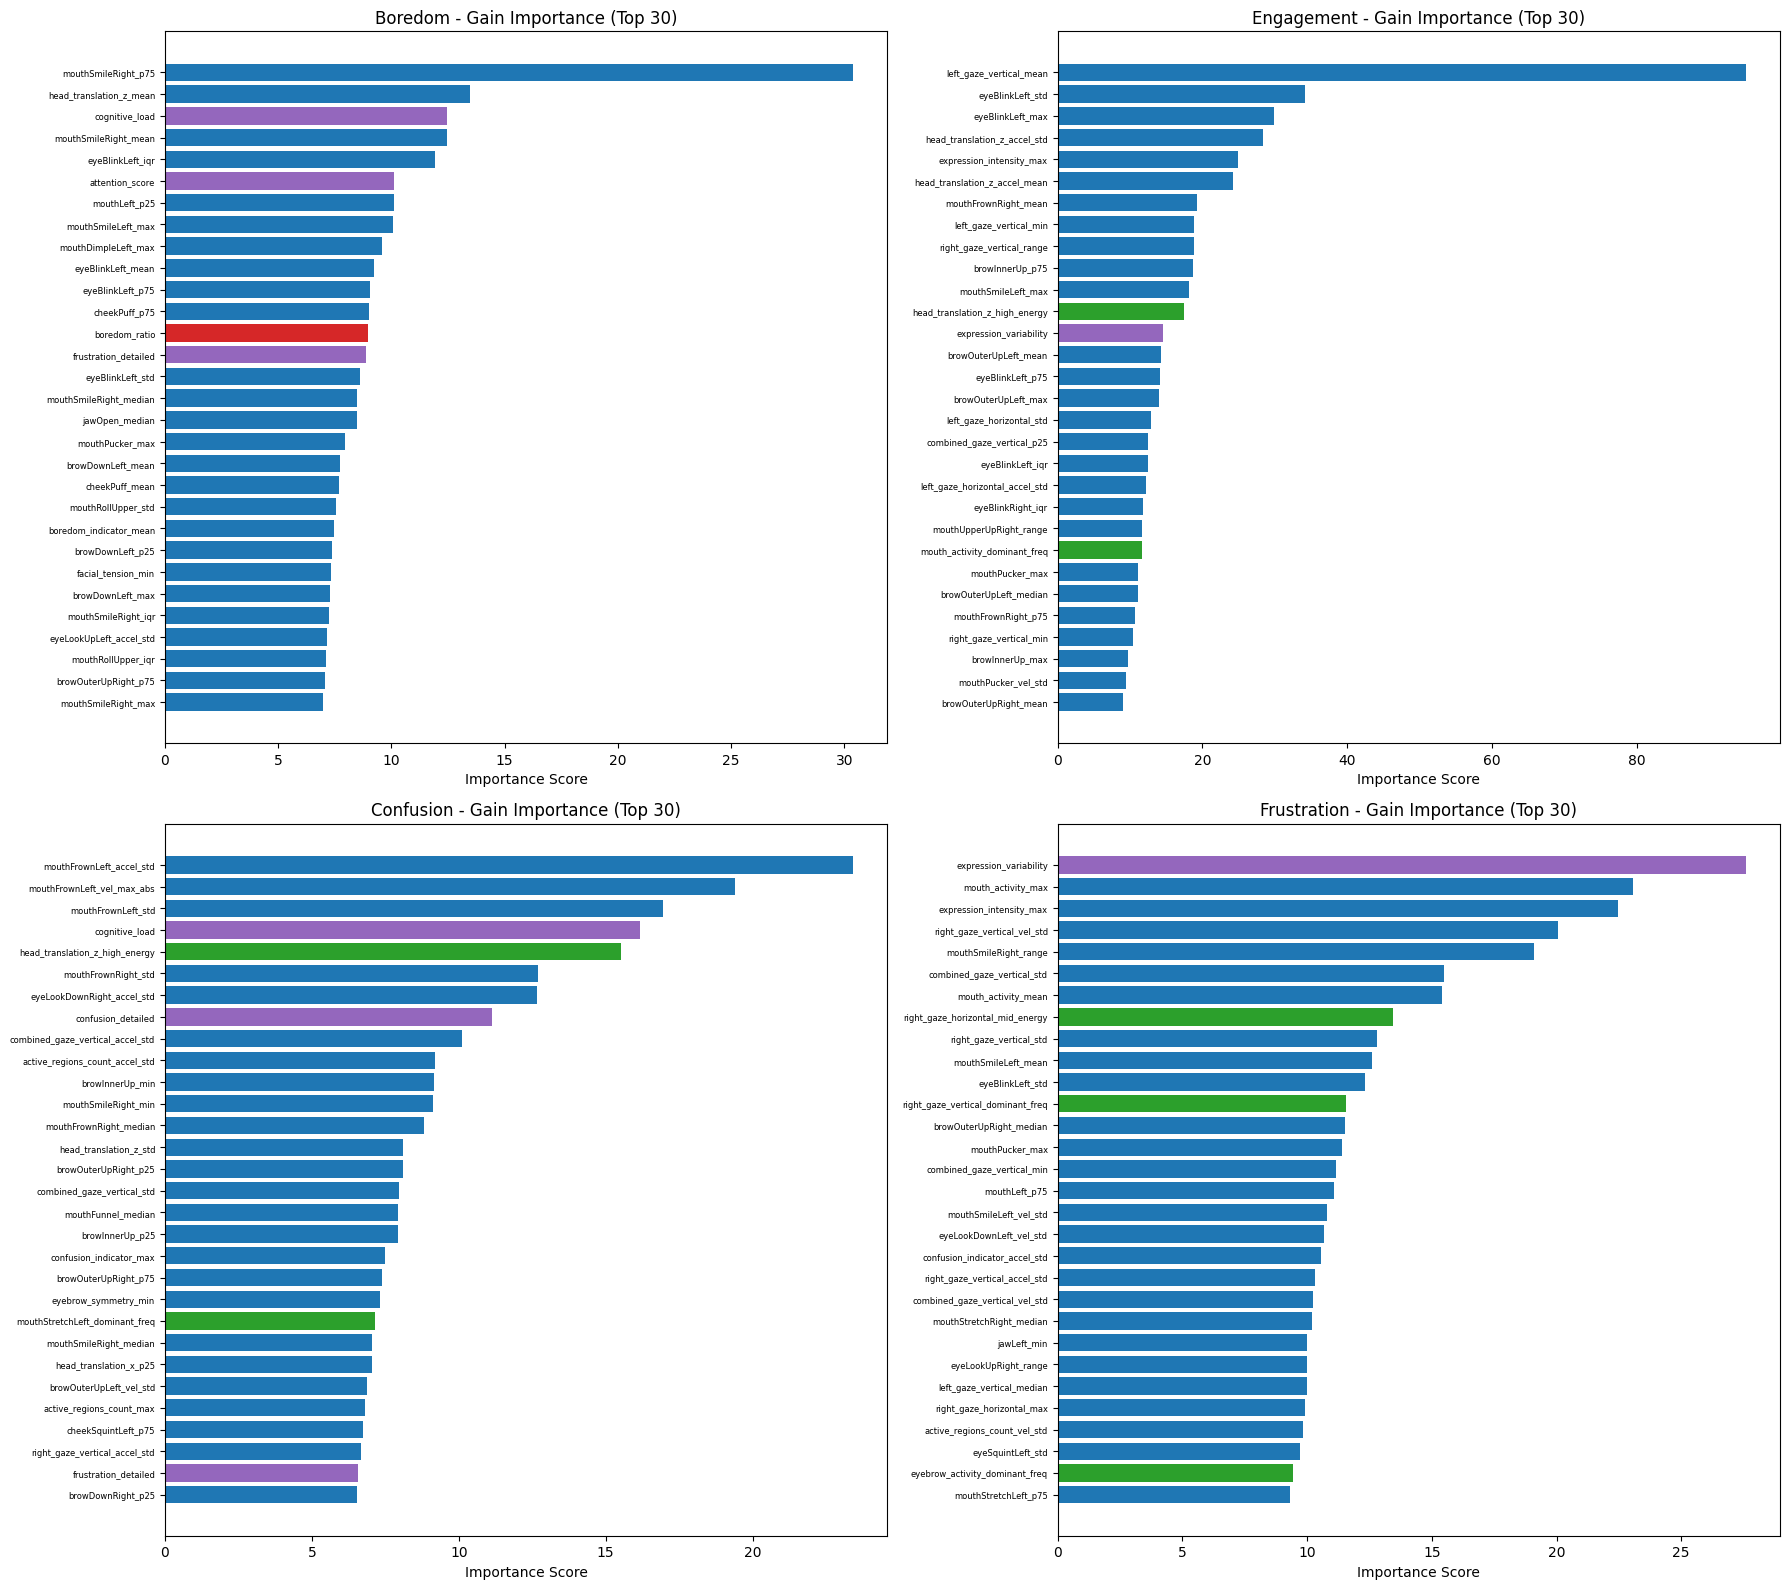

Saved: native_importance_gain.png


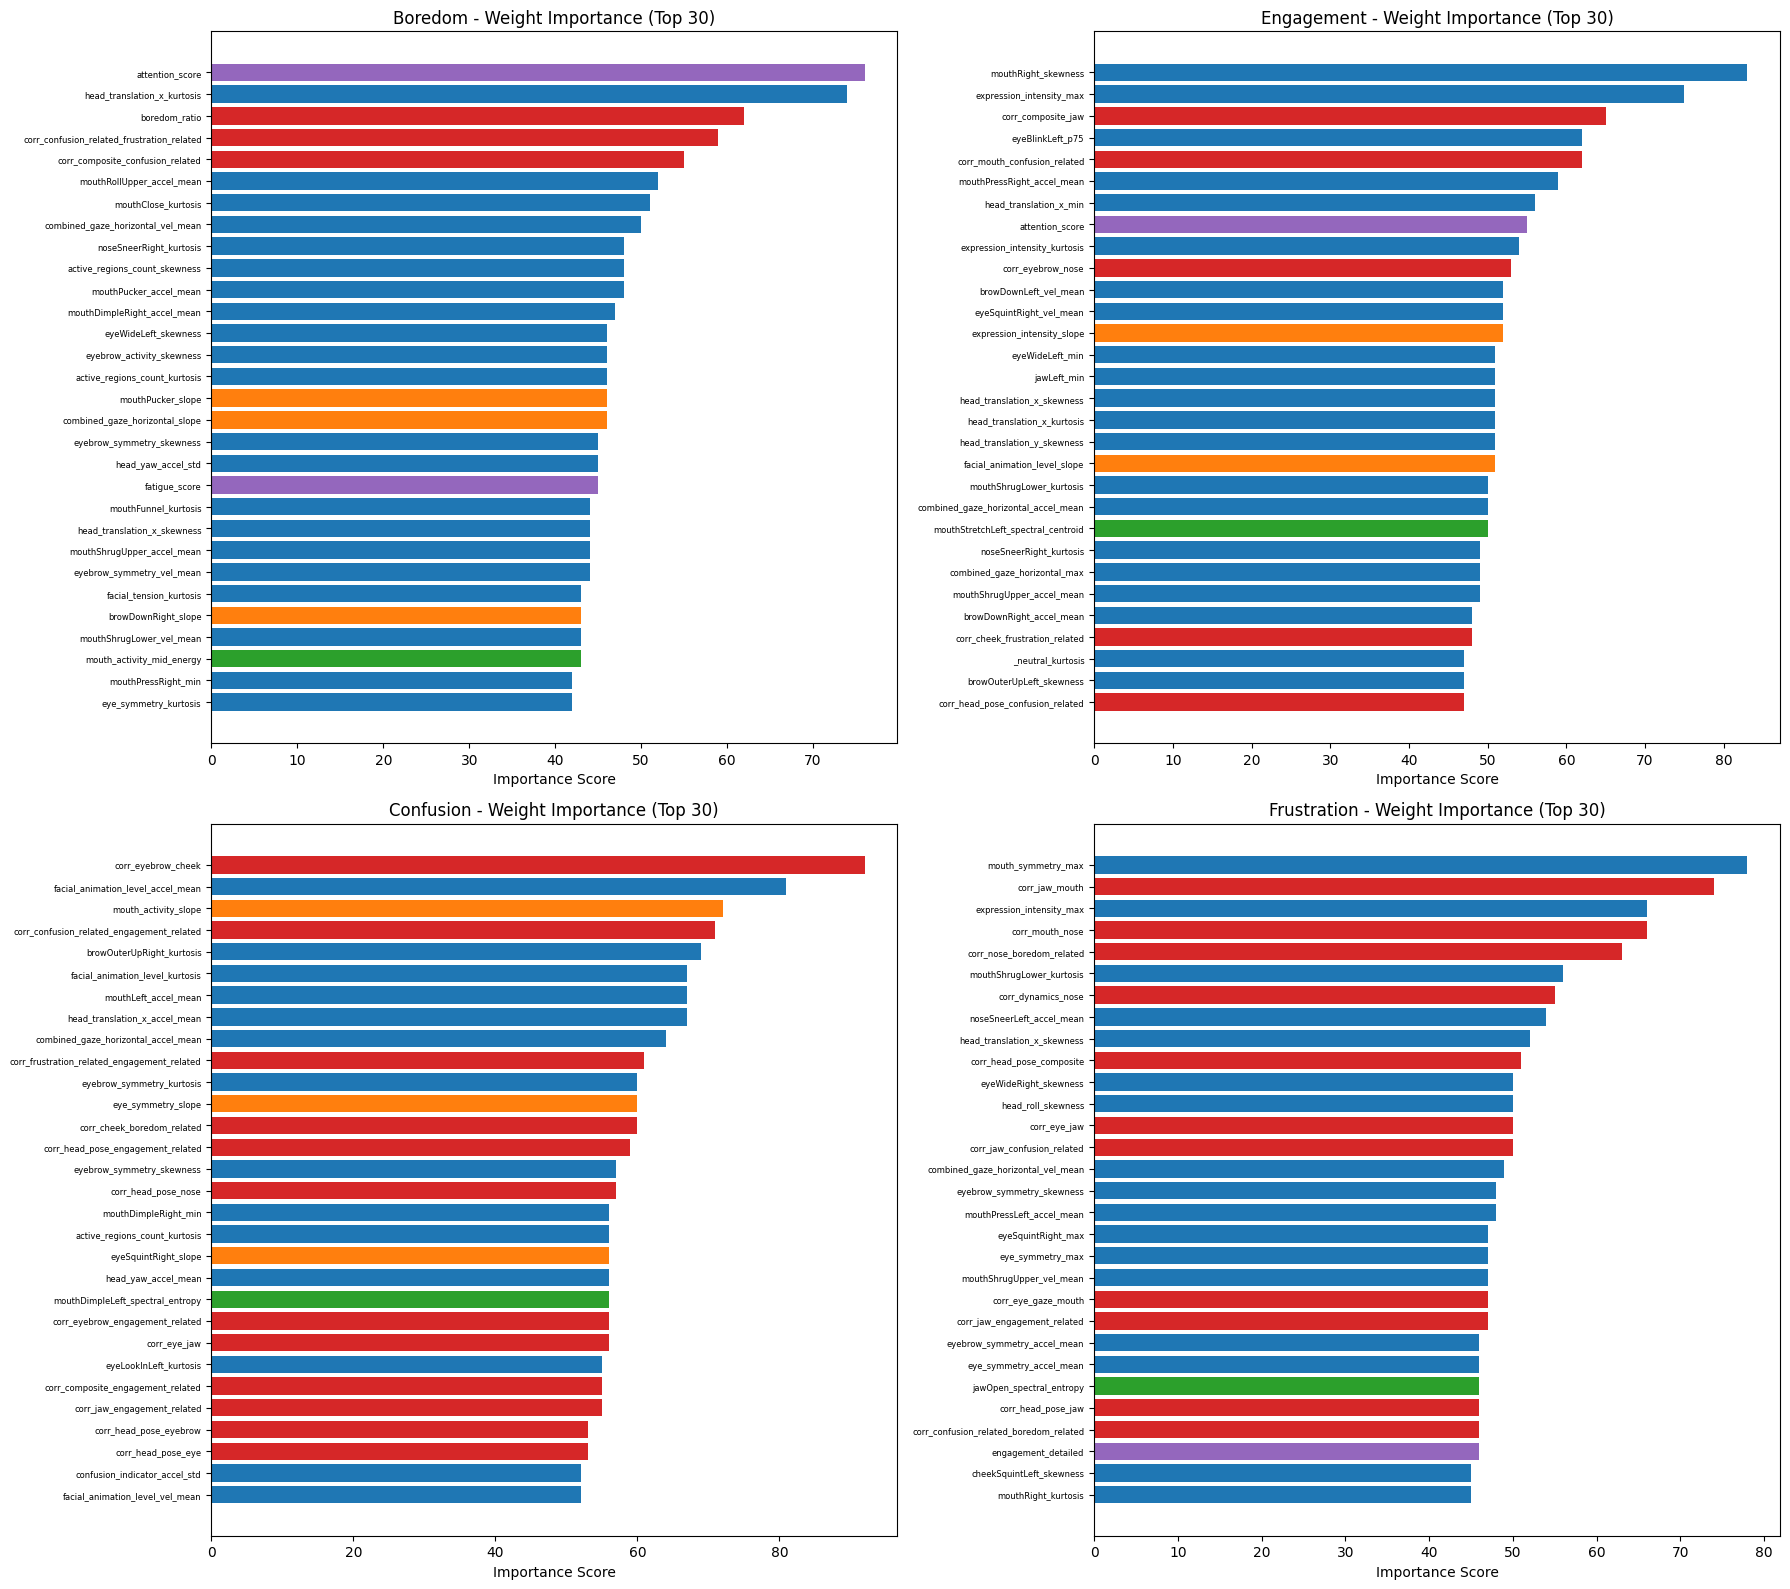

Saved: native_importance_weight.png


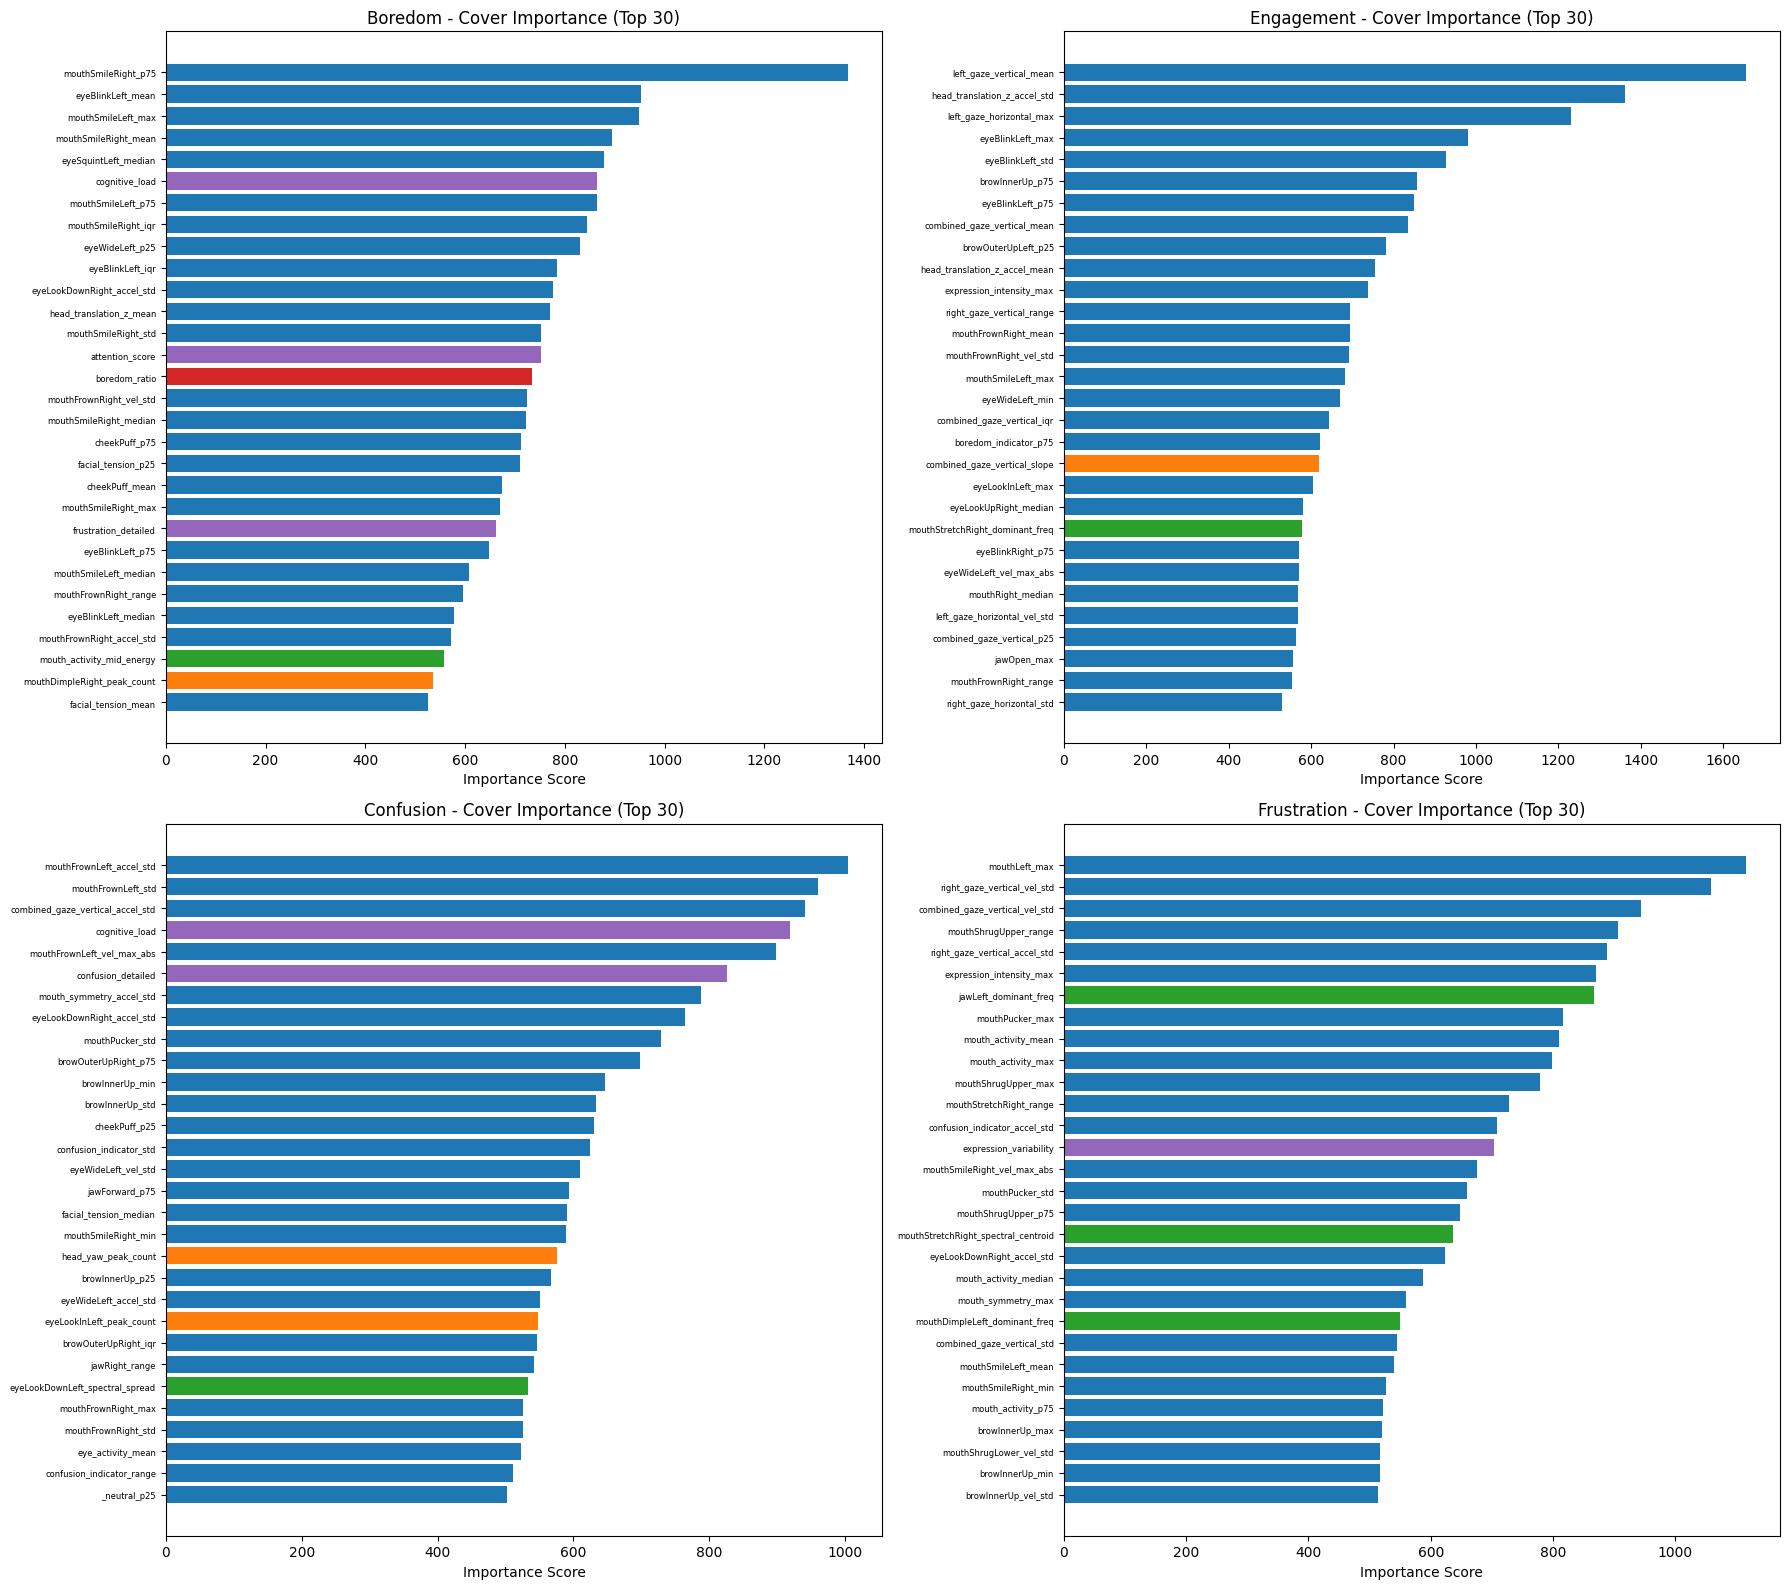

Saved: native_importance_cover.png


In [27]:
# Plot top-30 features for each state and importance type
for imp_type in importance_types:
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    axes = axes.flatten()
    
    for idx, state in enumerate(AFFECTIVE_STATES):
        ax = axes[idx]
        data = importance_data[imp_type][state][:30]
        
        features = [d[0] for d in data]
        scores = [d[1] for d in data]
        colors = [category_colors.get(get_feature_category(f), '#333333') for f in features]
        
        y_pos = np.arange(len(features))
        ax.barh(y_pos, scores, color=colors)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features, fontsize=6)
        ax.invert_yaxis()
        ax.set_xlabel('Importance Score')
        ax.set_title(f'{state.capitalize()} - {imp_type.capitalize()} Importance (Top 30)')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / f'native_importance_{imp_type}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: native_importance_{imp_type}.png")

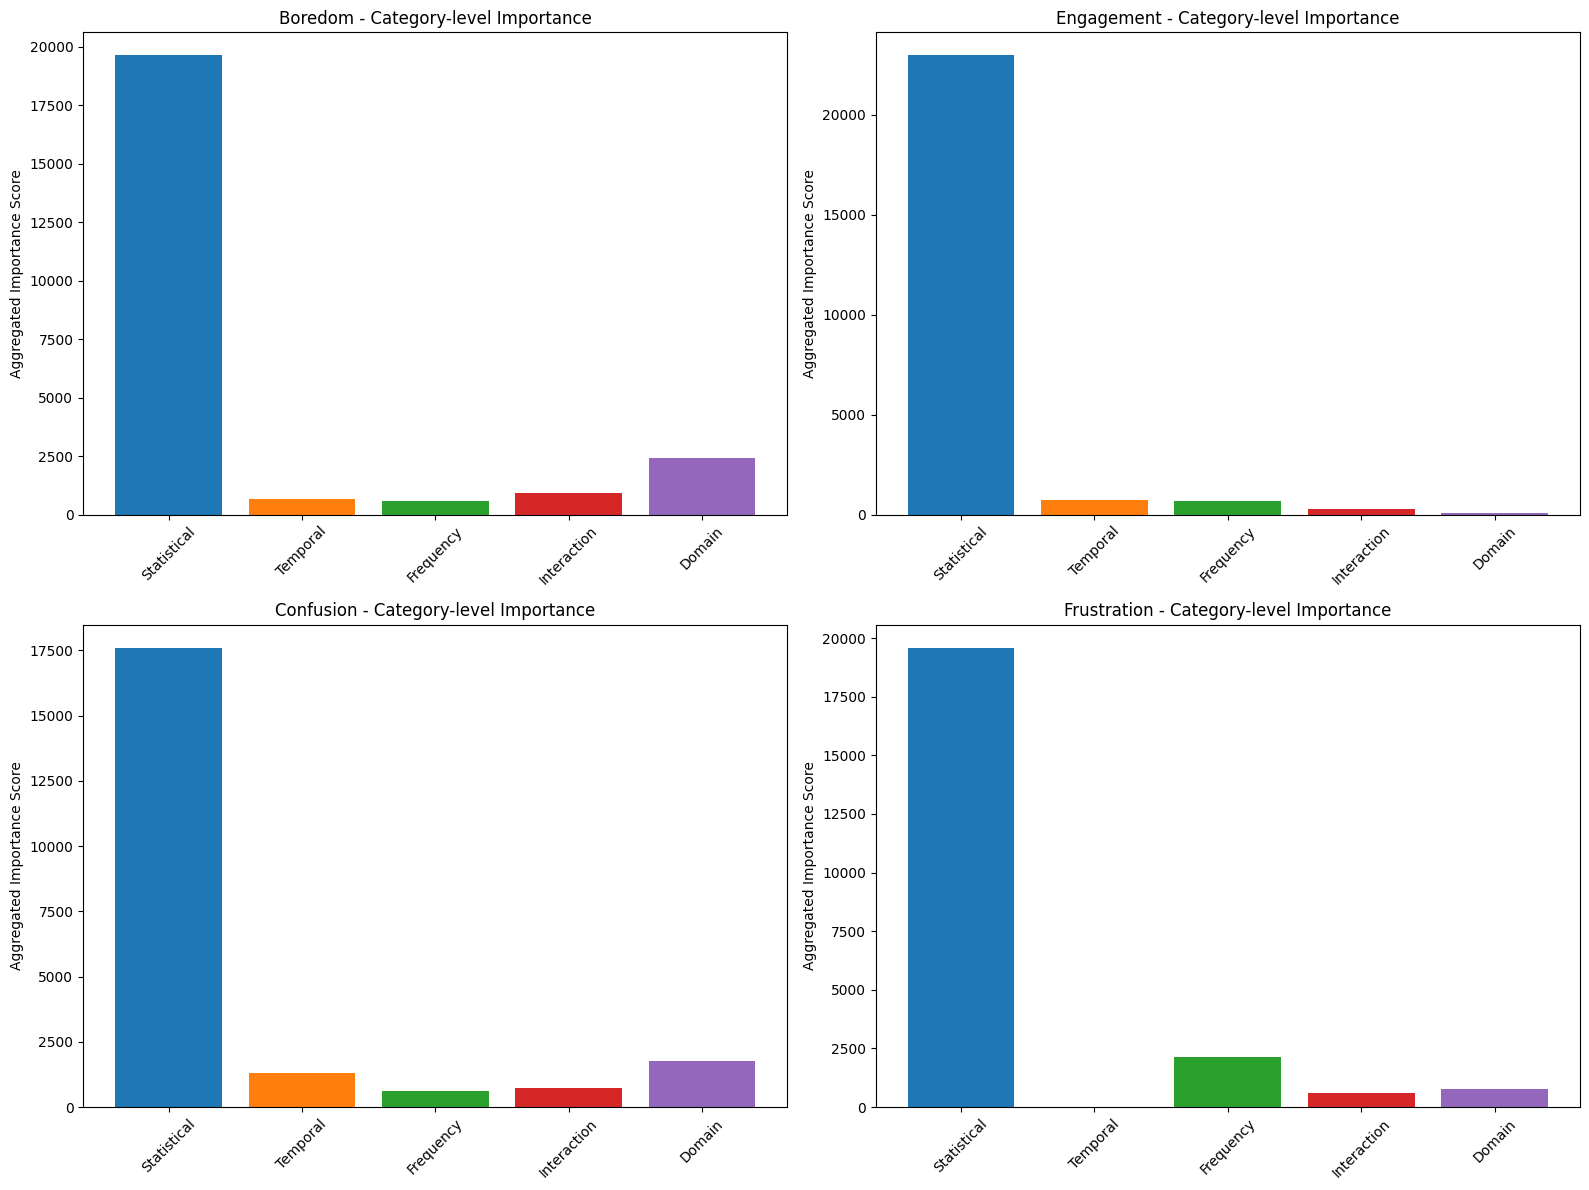

Saved: native_importance_categories.png


In [28]:
# Group-level aggregate importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, state in enumerate(AFFECTIVE_STATES):
    ax = axes[idx]
    
    category_scores = {cat: 0 for cat in category_colors.keys()}
    
    for imp_type in importance_types:
        for feat, score in importance_data[imp_type][state]:
            cat = get_feature_category(feat)
            category_scores[cat] += score
    
    cats = list(category_colors.keys())
    values = [category_scores[c] for c in cats]
    
    ax.bar(cats, values, color=[category_colors[c] for c in cats])
    ax.set_ylabel('Aggregated Importance Score')
    ax.set_title(f'{state.capitalize()} - Category-level Importance')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'native_importance_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: native_importance_categories.png")

---

## Section 4: LIME-based Feature Importance

In [29]:
import lime
import lime.lime_tabular

In [30]:
# LIME configuration - USER CONTROLS THIS CELL
N_LIME_SAMPLES = 100  # Number of samples to explain per state
RANDOM_STATE = 42

print(f"LIME configuration:")
print(f"  N_LIME_SAMPLES: {N_LIME_SAMPLES}")
print(f"  RANDOM_STATE: {RANDOM_STATE}")

LIME configuration:
  N_LIME_SAMPLES: 100
  RANDOM_STATE: 42


In [35]:
# Stratified sampling for each state
def stratified_sample_indices(y_state, n_samples, random_state=42):
    np.random.seed(random_state)
    classes, counts = np.unique(y_state, return_counts=True)
    indices = []
    for c in classes:
        c_idx = np.where(y_state == c)[0]
        n_c = max(1, int(n_samples * len(c_idx) / len(y_state)))
        indices.extend(np.random.choice(c_idx, size=min(n_c, len(c_idx)), replace=False).tolist())
    np.random.shuffle(indices)
    return indices[:n_samples]

lime_importance = {}

print("Running LIME importance analysis...")
for state in AFFECTIVE_STATES:
    print(f"\n  Processing {state}...")
    
    # Sample indices
    sample_idx = stratified_sample_indices(y_test[state], N_LIME_SAMPLES, RANDOM_STATE)
    X_sample = X_test_eng[sample_idx]
    
    # Create LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_sample,
        feature_names=eng_feature_names,
        class_names=CLASS_NAMES,
        mode='classification'
    )
    
    # Aggregate importance across samples
    feature_importance = np.zeros(len(eng_feature_names))
    
    for i, idx in enumerate(sample_idx):
        # Guard against zero/invalid scaler std that can cause truncnorm domain errors in LIME
        if hasattr(explainer, "scaler") and hasattr(explainer.scaler, "scale_"):
            explainer.scaler.scale_ = np.where(
            explainer.scaler.scale_ <= 1e-12, 1e-12, explainer.scaler.scale_
            )

        # Robust LIME call: sanitize row/pred inputs and handle truncnorm domain issues
        x_row = np.nan_to_num(np.asarray(X_test_eng[idx], dtype=np.float64), nan=0.0, posinf=1e6, neginf=-1e6)

        predict_fn = lambda z: model.models[state].predict_proba(
            np.nan_to_num(np.asarray(z, dtype=np.float32), nan=0.0, posinf=1e6, neginf=-1e6)
        )

        try:
            exp = explainer.explain_instance(
                x_row,
                predict_fn,
                num_features=len(eng_feature_names),
                num_samples=2000
            )
        except ValueError as e:
            if "Domain error in arguments" not in str(e):
                raise

            # Fallback: disable discretizer path (which uses truncnorm) and retry
            if hasattr(explainer, "discretizer"):
                explainer.discretizer = None
            if hasattr(explainer, "scaler") and hasattr(explainer.scaler, "scale_"):
                explainer.scaler.scale_ = np.where(
                    np.isfinite(explainer.scaler.scale_) & (explainer.scaler.scale_ > 1e-12),
                    explainer.scaler.scale_,
                    1e-12
                )

            exp = explainer.explain_instance(
                x_row,
                predict_fn,
                num_features=len(eng_feature_names),
                num_samples=1000
            )
        
        # Get feature weights (use numeric feature ids to avoid string parsing issues like "feature=0")
        if hasattr(exp, "local_exp") and exp.local_exp:
            if hasattr(exp, "predict_proba") and exp.predict_proba is not None:
                label_key = int(np.argmax(exp.predict_proba))
            else:
                label_key = next(iter(exp.local_exp.keys()))

            for feat_idx, weight in exp.local_exp.get(label_key, []):
                if 0 <= feat_idx < len(feature_importance):
                    feature_importance[feat_idx] += abs(weight)
    
    # Average
    feature_importance /= len(sample_idx)
    
    # Store top 30
    top_idx = np.argsort(feature_importance)[::-1][:30]
    lime_importance[state] = [(eng_feature_names[i], feature_importance[i]) for i in top_idx]
    
    print(f"    Done: {len(sample_idx)} samples explained")

Running LIME importance analysis...

  Processing boredom...
    Done: 98 samples explained

  Processing engagement...
    Done: 98 samples explained

  Processing confusion...
    Done: 99 samples explained

  Processing frustration...
    Done: 99 samples explained


In [36]:
# Display LIME importance
print("\n" + "="*60)
print("LIME Feature Importance (Top 30 per State)")
print("="*60)

for state in AFFECTIVE_STATES:
    print(f"\n--- {state.upper()} ---")
    df = pd.DataFrame(lime_importance[state], columns=["Feature", "Importance"])[
        :10
    ]
    print(df.to_string(index=False))


LIME Feature Importance (Top 30 per State)

--- BOREDOM ---
                             Feature  Importance
       head_translation_z_accel_mean    0.001919
         head_translation_z_vel_mean    0.001347
              head_translation_z_iqr    0.001245
       head_translation_z_peak_count    0.000933
head_translation_z_spectral_centroid    0.000765
              head_translation_z_std    0.000729
            head_translation_z_slope    0.000723
  head_translation_z_spectral_spread    0.000712
               head_pitch_accel_mean    0.000707
       head_translation_z_mid_energy    0.000681

--- ENGAGEMENT ---
                            Feature  Importance
             head_translation_z_iqr    0.010962
      head_translation_z_accel_mean    0.009176
           head_translation_z_slope    0.008541
      head_translation_z_peak_count    0.008286
        head_translation_z_vel_mean    0.008134
   head_translation_z_dominant_freq    0.006213
 head_translation_z_spectral_spread    0.006

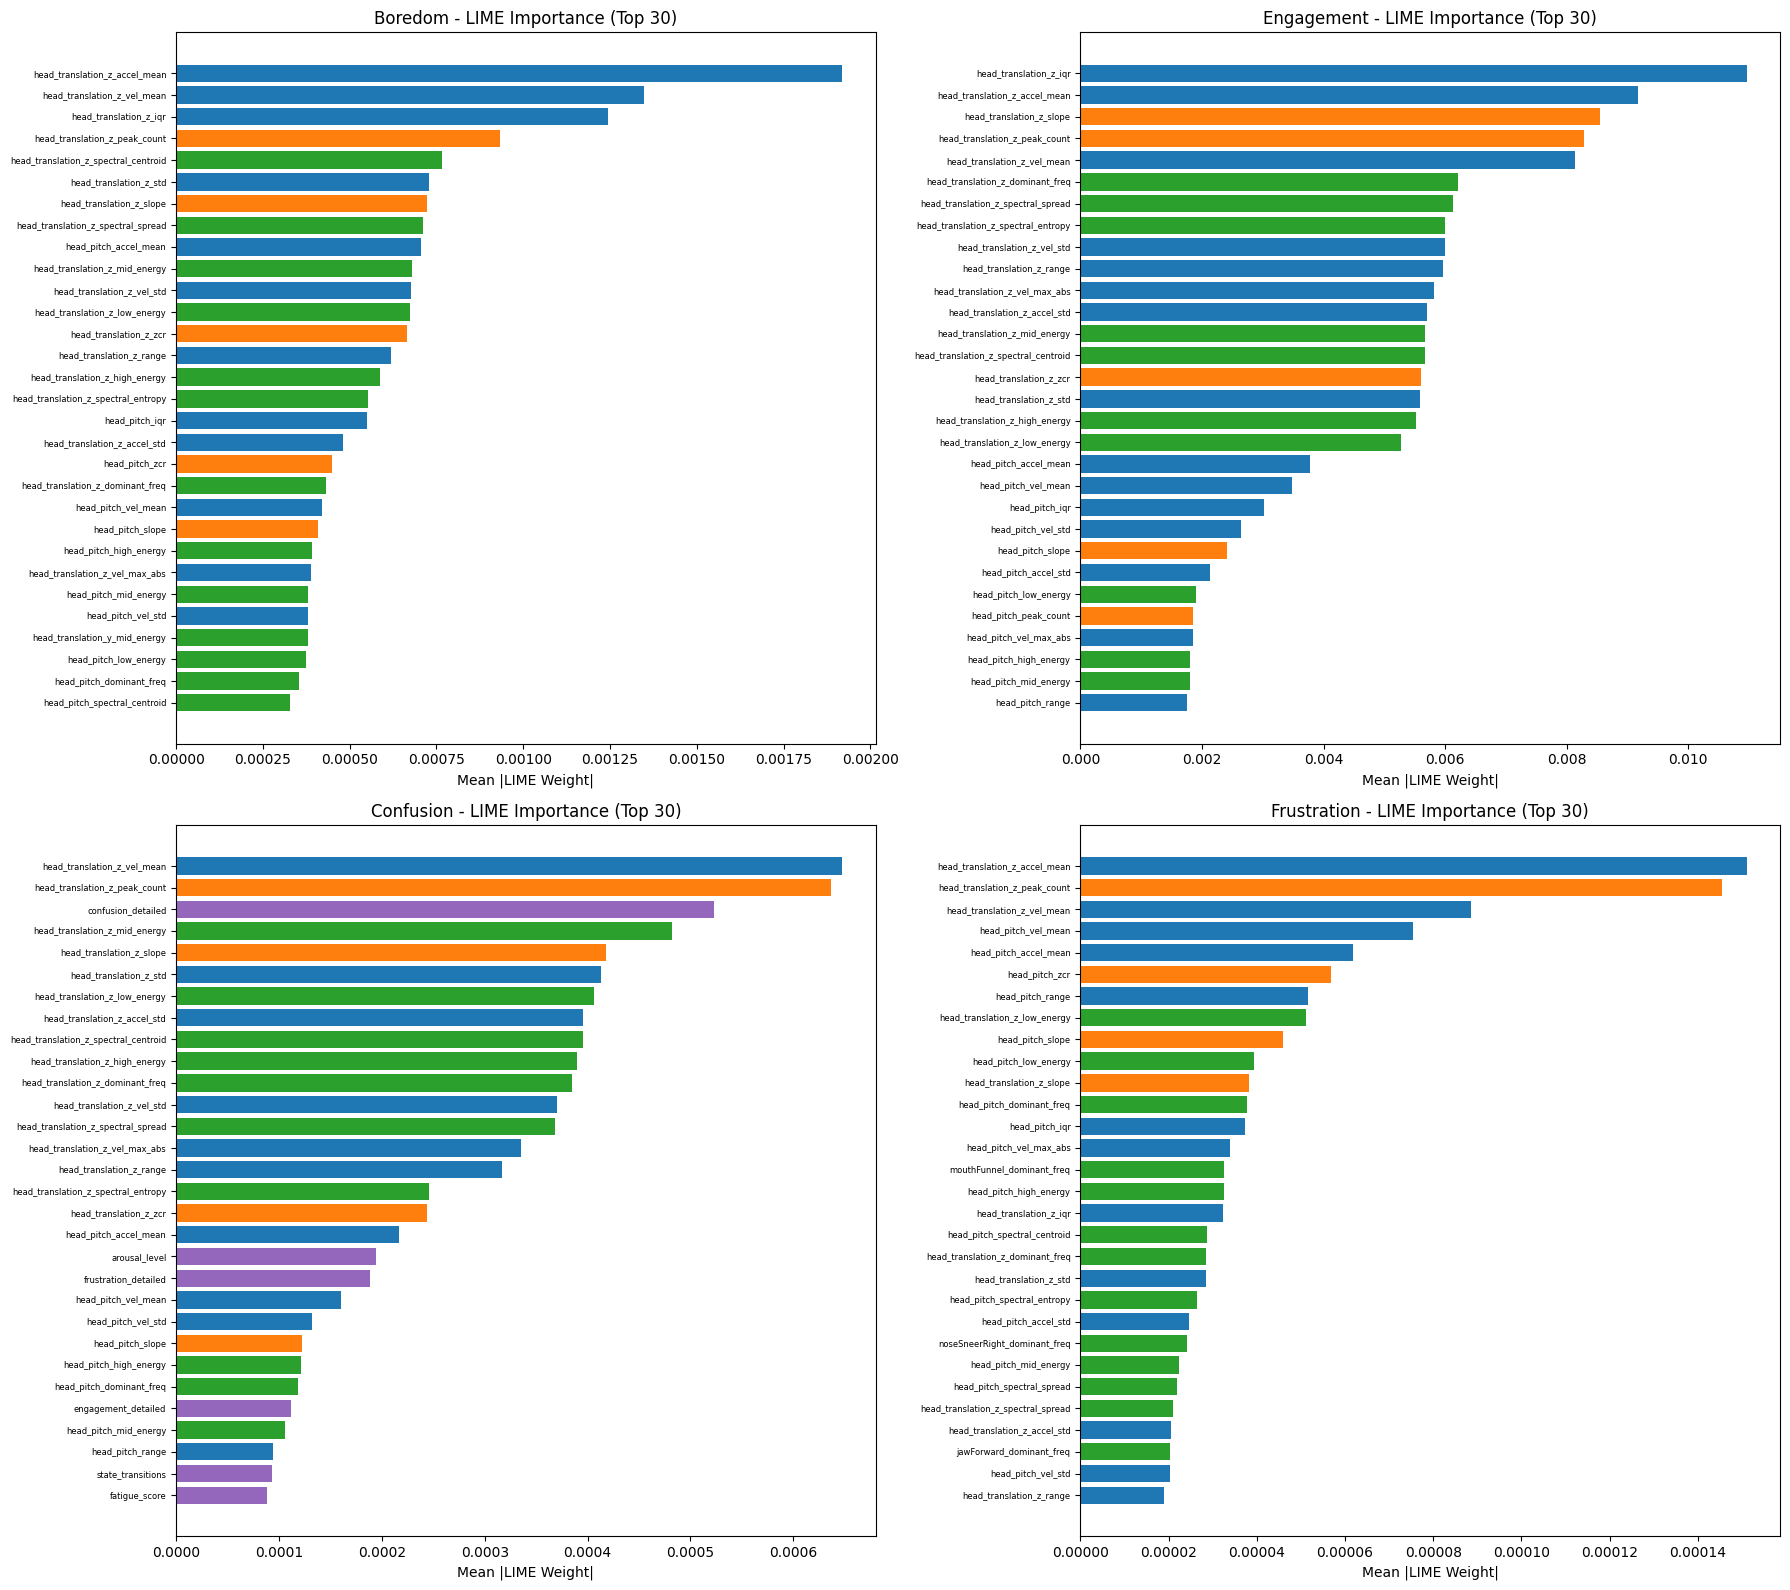

Saved: lime_importance.png


In [37]:
# Plot LIME importance
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, state in enumerate(AFFECTIVE_STATES):
    ax = axes[idx]
    
    data = lime_importance[state][:30]
    features = [d[0] for d in data]
    scores = [d[1] for d in data]
    colors = [category_colors.get(get_feature_category(f), '#333333') for f in features]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, scores, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=6)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |LIME Weight|')
    ax.set_title(f'{state.capitalize()} - LIME Importance (Top 30)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'lime_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lime_importance.png")

---

## Section 5: SHAP-based Feature Importance

In [38]:
import shap

In [39]:
# SHAP configuration
N_SHAP_SAMPLES = 200  # Use subset for speed; set None for full test set
RANDOM_STATE = 42

print(f"SHAP configuration:")
print(f"  N_SHAP_SAMPLES: {N_SHAP_SAMPLES}")

SHAP configuration:
  N_SHAP_SAMPLES: 200


In [41]:
# Compute SHAP values for each state
shap_importance = {}

print("Computing SHAP values...")
for state in AFFECTIVE_STATES:
    print(f"\n  Processing {state}...")
    
    # Use subset for speed
    if N_SHAP_SAMPLES:
        np.random.seed(RANDOM_STATE)
        sample_idx = np.random.choice(len(X_test_eng), N_SHAP_SAMPLES, replace=False)
        X_sample = X_test_eng[sample_idx]
    else:
        X_sample = X_test_eng
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model.models[state])
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_sample)
    
    # For multi-class, take mean absolute value across classes
    if isinstance(shap_values, list):
        # Multi-class: list of arrays, take mean across classes
        mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(shap_values)
    
    # Global importance: mean across samples
    global_importance = np.mean(mean_abs_shap, axis=0)
    
    # Top 30
    top_idx = np.argsort(global_importance)[::-1][:30]
    # Ensure 1D importance vector (handle multi-class SHAP output)
    if np.ndim(global_importance) > 1:
        global_importance = np.mean(global_importance, axis=-1)

    # Recompute top indices as 1D integer indices
    top_idx = np.argsort(global_importance)[::-1][:30].astype(int)

    shap_importance[state] = [
        (eng_feature_names[i], float(global_importance[i]))
        for i in top_idx
    ]
    
    print(f"    Done: {X_sample.shape[0]} samples explained")

Computing SHAP values...

  Processing boredom...
    Done: 200 samples explained

  Processing engagement...
    Done: 200 samples explained

  Processing confusion...
    Done: 200 samples explained

  Processing frustration...
    Done: 200 samples explained


In [42]:
# Display SHAP importance
print("\n" + "="*60)
print("SHAP Feature Importance (Top 30 per State)")
print("="*60)

for state in AFFECTIVE_STATES:
    print(f"\n--- {state.upper()} ---")
    df = pd.DataFrame(shap_importance[state], columns=["Feature", "Mean |SHAP|"])[
        :10
    ]
    print(df.to_string(index=False))


SHAP Feature Importance (Top 30 per State)

--- BOREDOM ---
                  Feature  Mean |SHAP|
            mouthLeft_p25     0.042192
      mouthSmileRight_p75     0.034509
          attention_score     0.022132
right_gaze_horizontal_iqr     0.016449
            boredom_ratio     0.016188
         eyeBlinkLeft_iqr     0.015990
      mouthPressRight_min     0.015766
         eyeBlinkLeft_std     0.014932
            arousal_level     0.013694
        eyeBlinkLeft_mean     0.013408

--- ENGAGEMENT ---
                     Feature  Mean |SHAP|
left_gaze_horizontal_vel_std     0.082073
   right_gaze_horizontal_std     0.043889
            eyeBlinkLeft_p75     0.035002
    expression_intensity_max     0.025404
            eyeBlinkLeft_std     0.023798
            eyeBlinkLeft_max     0.022905
           eyeBlinkRight_p75     0.022198
             eyeWideLeft_min     0.021599
  mouthPressRight_accel_mean     0.021561
    left_gaze_horizontal_max     0.021184

--- CONFUSION ---
         

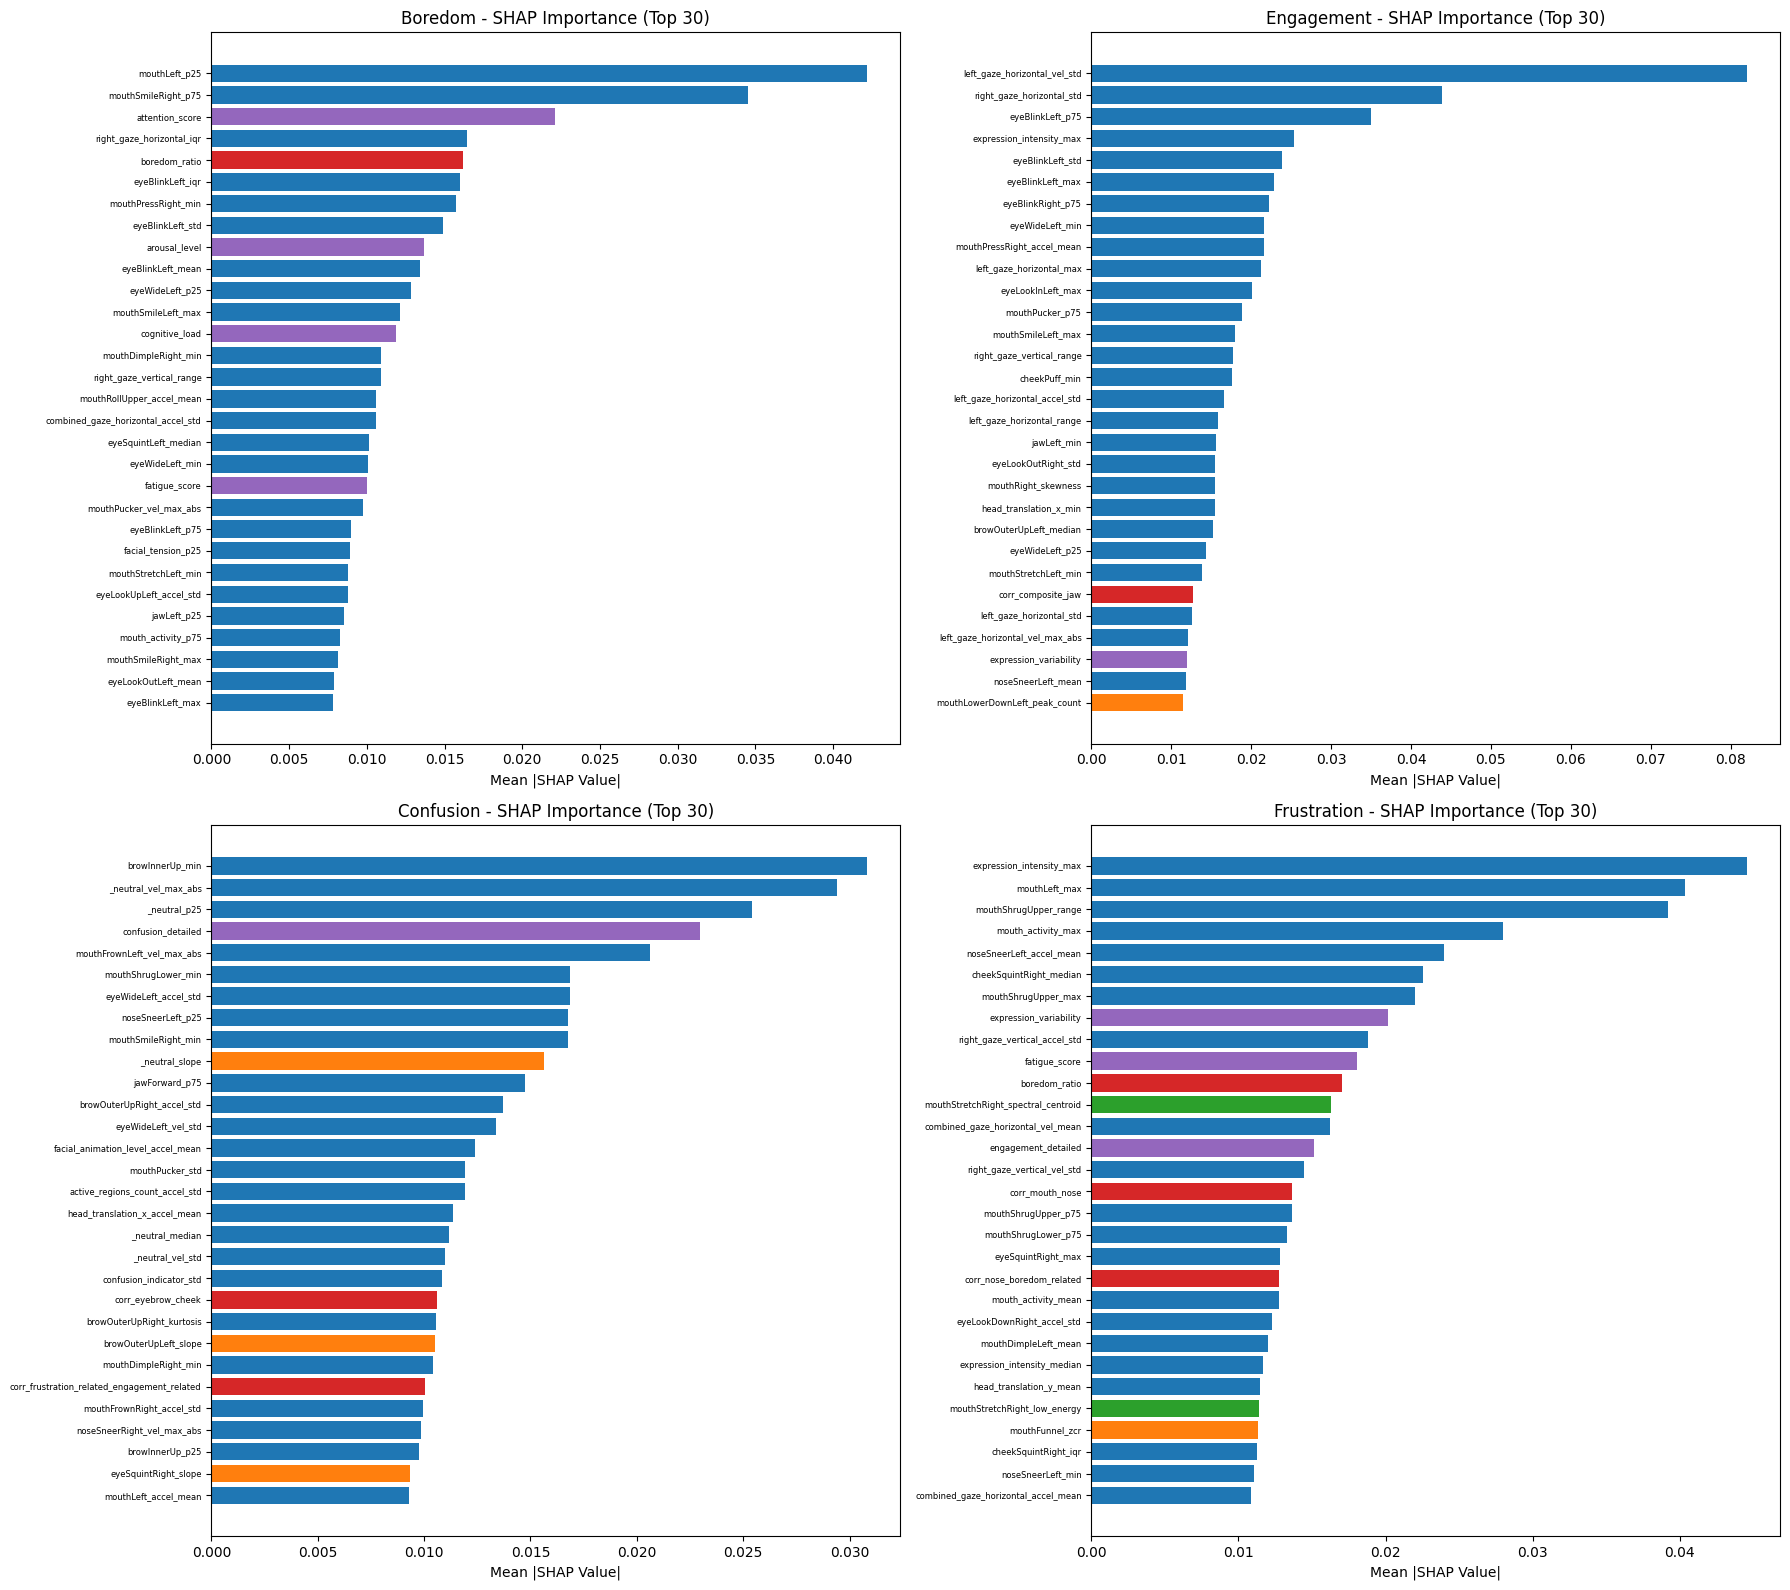

Saved: shap_importance.png


In [43]:
# Plot SHAP importance
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, state in enumerate(AFFECTIVE_STATES):
    ax = axes[idx]
    
    data = shap_importance[state][:30]
    features = [d[0] for d in data]
    scores = [d[1] for d in data]
    colors = [category_colors.get(get_feature_category(f), '#333333') for f in features]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, scores, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=6)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title(f'{state.capitalize()} - SHAP Importance (Top 30)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance.png")

---

## Section 6: Permutation Feature Importance

In [44]:
from sklearn.inspection import permutation_importance

In [45]:
# PFI Configuration - USER CONTROLS THIS CELL
PFI_CONFIG = {
    "n_repeats": 10,
    "scoring": "f1_macro",
    "random_state": 42,
    "prefilter_top_k": None  # None = Option A (full), int = Option B (prefiltered)
}

print("PFI Configuration:")
for k, v in PFI_CONFIG.items():
    print(f"  {k}: {v}")

if PFI_CONFIG["prefilter_top_k"] is None:
    print("\n>>> Running OPTION A: Full ~2000+ feature PFI (slow, ~10-30 min)")
else:
    print(f"\n>>> Running OPTION B: Prefiltered to top-{PFI_CONFIG['prefilter_top_k']} by gain (fast, ~5 min)")

PFI Configuration:
  n_repeats: 10
  scoring: f1_macro
  random_state: 42
  prefilter_top_k: None

>>> Running OPTION A: Full ~2000+ feature PFI (slow, ~10-30 min)


In [46]:
# Helper function to run PFI
def run_permutation_importance(model, state, X, y, eng_names, config):
    """
    Run permutation importance with optional prefiltering.
    
    Args:
        model: XGBClassifier for the state
        state: state name
        X: feature matrix
        y: labels
        eng_names: feature names
        config: dict with n_repeats, scoring, random_state, prefilter_top_k
    """
    X_arr = np.array(X)
    y_arr = np.array(y)
    
    # Option B: Prefilter by gain
    if config.get("prefilter_top_k"):
        k = config["prefilter_top_k"]
        gain_imp = model.get_booster().get_score(importance_type="gain")
        
        # Get top K feature indices
        sorted_gain = sorted(gain_imp.items(), key=lambda x: x[1], reverse=True)[:k]
        top_indices = [int(f.replace("f", "")) for f, _ in sorted_gain]
        
        X_arr = X_arr[:, top_indices]
        eng_names = [eng_names[i] for i in top_indices]
        print(f"    Prefiltered to {len(top_indices)} features by gain")
    
    # Run permutation importance
    result = permutation_importance(
        model,
        X_arr,
        y_arr,
        n_repeats=config["n_repeats"],
        scoring=config["scoring"],
        random_state=config["random_state"],
        n_jobs=-1
    )
    
    # Build DataFrame
    df = pd.DataFrame({
        "feature": eng_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return df

In [47]:
# Run PFI for all states
import time
pfi_results = {}

print("\nRunning Permutation Feature Importance...")
start_time = time.time()

for state in AFFECTIVE_STATES:
    print(f"\n  {state.upper()}:")
    state_start = time.time()
    
    df = run_permutation_importance(
        model.models[state],
        state,
        X_test_eng,
        y_test[state],
        eng_feature_names,
        PFI_CONFIG
    )
    
    pfi_results[state] = df
    
    state_time = time.time() - state_start
    print(f"    Completed in {state_time:.1f}s")

total_time = time.time() - start_time
print(f"\n>>> Total PFI time: {total_time:.1f}s ({total_time/60:.1f} min)")


Running Permutation Feature Importance...

  BOREDOM:
    Completed in 36.8s

  ENGAGEMENT:
    Completed in 41.5s

  CONFUSION:
    Completed in 47.5s

  FRUSTRATION:
    Completed in 44.4s

>>> Total PFI time: 170.3s (2.8 min)


In [48]:
# Display PFI results
print("\n" + "="*60)
print("Permutation Feature Importance (Top 30 per State)")
print("="*60)

for state in AFFECTIVE_STATES:
    print(f"\n--- {state.upper()} ---")
    print(pfi_results[state].head(10).to_string(index=False))


Permutation Feature Importance (Top 30 per State)

--- BOREDOM ---
             feature  importance_mean  importance_std
       fatigue_score         0.009392        0.002597
     attention_score         0.007256        0.003510
       corr_jaw_nose         0.006106        0.001533
   eyeBlinkLeft_mean         0.005494        0.004169
     eyeWideLeft_p25         0.005490        0.003187
       arousal_level         0.005110        0.002846
    browDownLeft_p25         0.004479        0.001511
eyeWideLeft_skewness         0.004423        0.002099
      cognitive_load         0.004292        0.002508
mouthFrownRight_mean         0.004224        0.000950

--- ENGAGEMENT ---
                      feature  importance_mean  importance_std
          mouthRight_skewness         0.015908        0.005242
            eyeBlinkRight_p75         0.014603        0.008397
     expression_intensity_max         0.014367        0.009591
mouthLowerDownLeft_peak_count         0.014187        0.007426
   

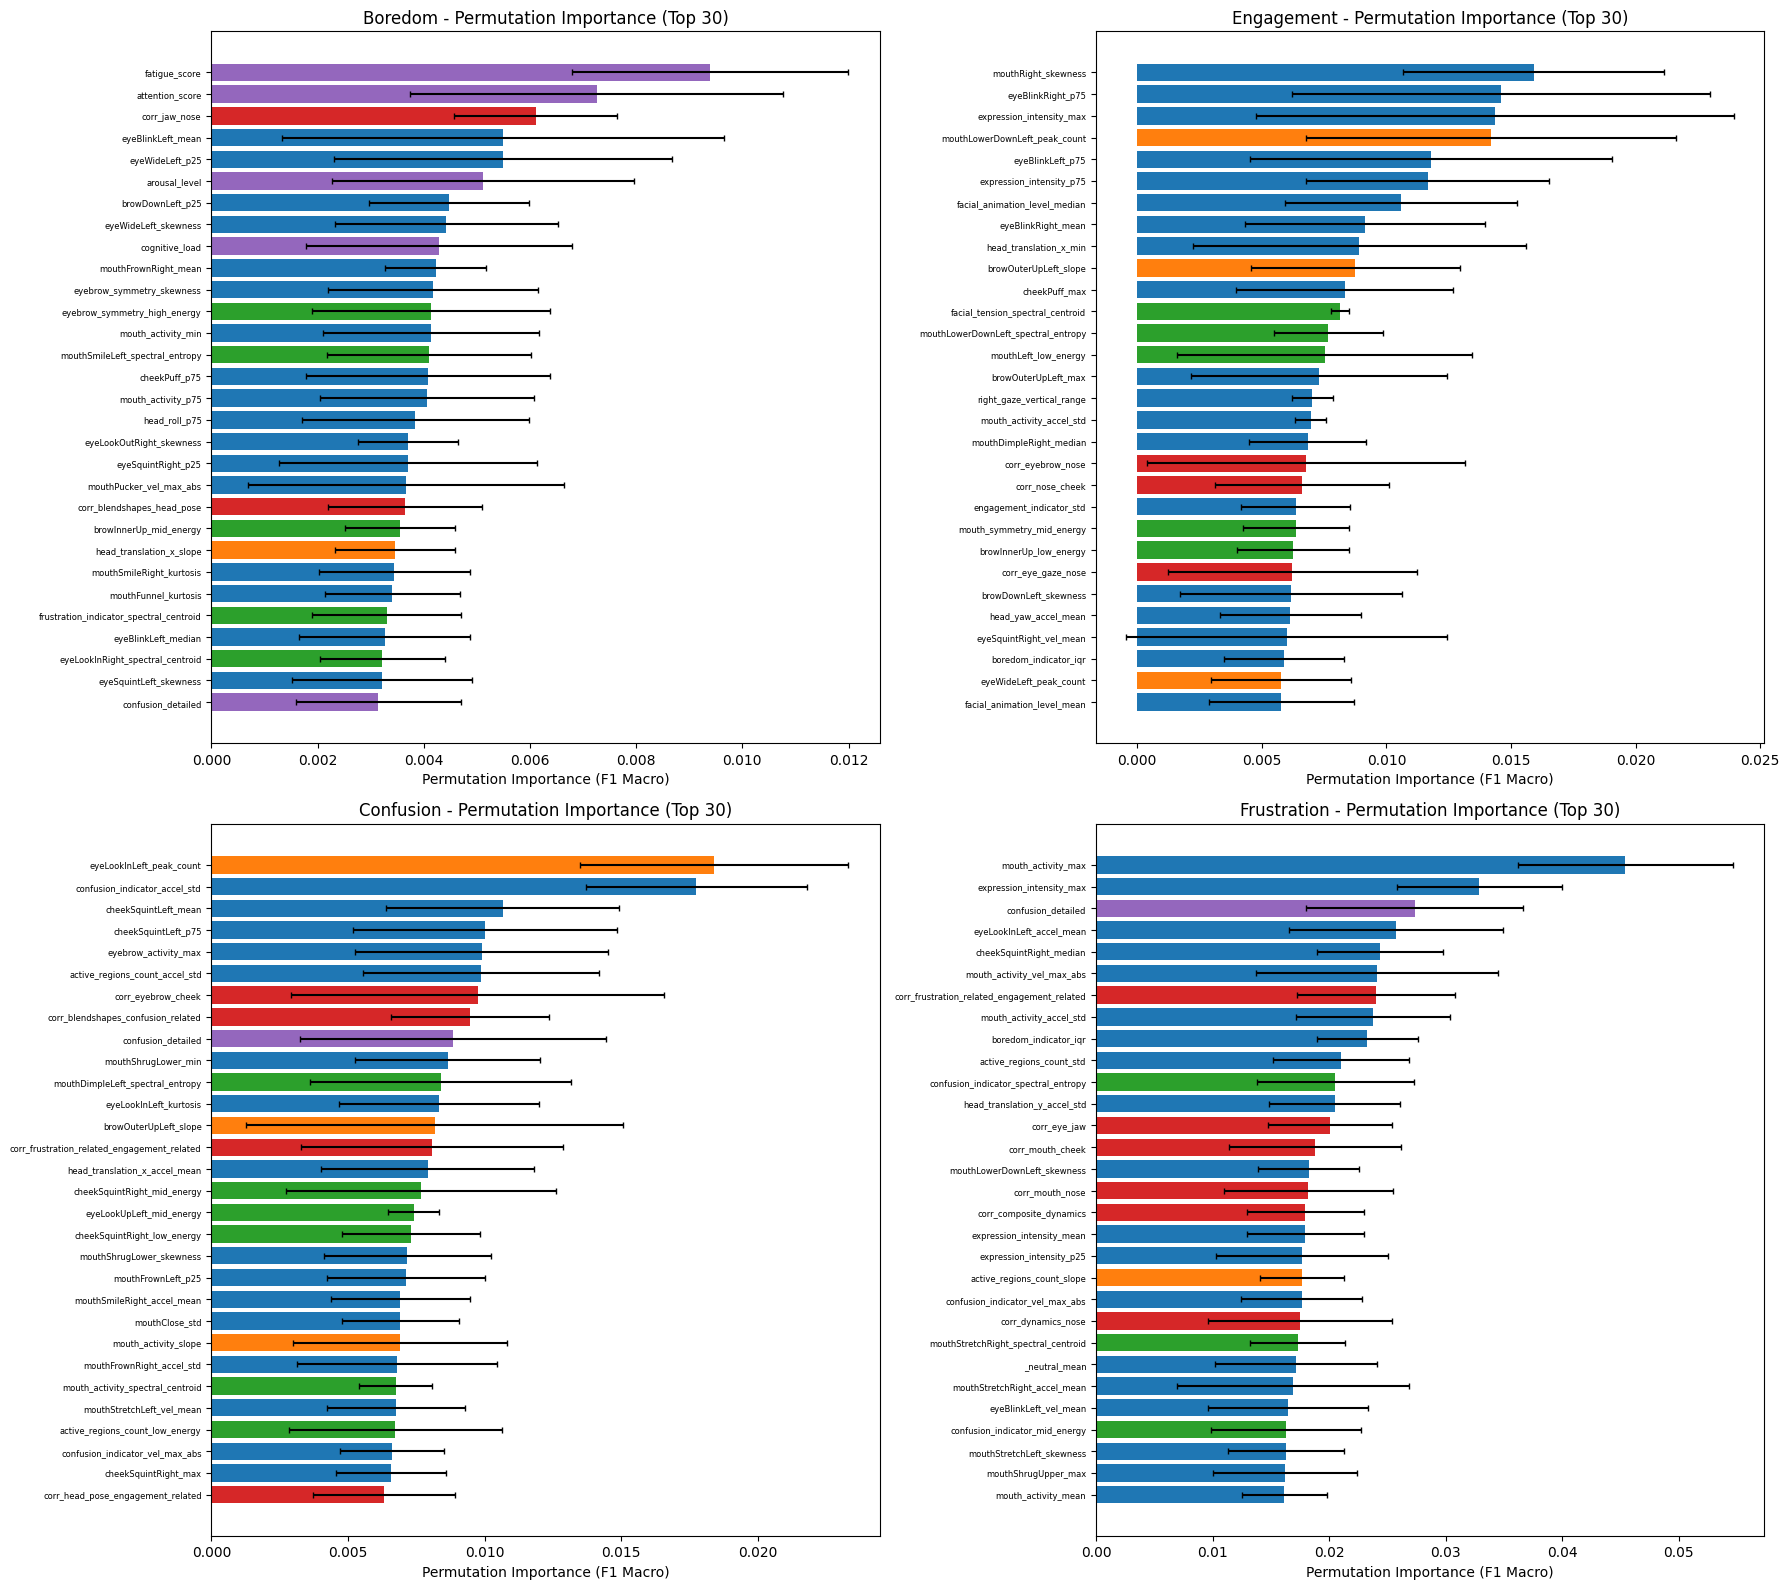

Saved: permutation_importance.png


In [49]:
# Plot PFI importance
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, state in enumerate(AFFECTIVE_STATES):
    ax = axes[idx]
    
    df = pfi_results[state].head(30)
    features = df["feature"].tolist()
    scores = df["importance_mean"].tolist()
    errors = df["importance_std"].tolist()
    colors = [category_colors.get(get_feature_category(f), '#333333') for f in features]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, scores, xerr=errors, color=colors, capsize=2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=6)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation Importance (F1 Macro)')
    ax.set_title(f'{state.capitalize()} - Permutation Importance (Top 30)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: permutation_importance.png")

In [50]:
# Save PFI results to CSV
for state in AFFECTIVE_STATES:
    csv_path = OUTPUT_DIR / 'evaluation' / state / 'permutation_importance.csv'
    pfi_results[state].to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

# Combined summary
summary_rows = []
for state in AFFECTIVE_STATES:
    top5 = pfi_results[state].head(5)
    for _, row in top5.iterrows():
        summary_rows.append({
            "state": state,
            "feature": row["feature"],
            "importance_mean": row["importance_mean"],
            "importance_std": row["importance_std"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / 'evaluation' / 'permutation_importance_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved: {summary_path}")

Saved: ../outputs_v2/xgboost/latest/evaluation/boredom/permutation_importance.csv
Saved: ../outputs_v2/xgboost/latest/evaluation/engagement/permutation_importance.csv
Saved: ../outputs_v2/xgboost/latest/evaluation/confusion/permutation_importance.csv
Saved: ../outputs_v2/xgboost/latest/evaluation/frustration/permutation_importance.csv

Saved: ../outputs_v2/xgboost/latest/evaluation/permutation_importance_summary.csv


---

## Summary

In [51]:
print("="*70)
print("Feature Importance Study Complete!")
print("="*70)

print("\nGenerated outputs:")
print("  • Native importance plots (gain, weight, cover)")
print("  • Category-level importance aggregation")
print("  • LIME importance plots")
print("  • SHAP importance plots")
print("  • Permutation importance plots")
print("  • CSV files for PFI results")

print(f"\nOutput directory: {OUTPUT_DIR / 'plots'}")

Feature Importance Study Complete!

Generated outputs:
  • Native importance plots (gain, weight, cover)
  • Category-level importance aggregation
  • LIME importance plots
  • SHAP importance plots
  • Permutation importance plots
  • CSV files for PFI results

Output directory: ../outputs_v2/xgboost/latest/plots


In [52]:
# Quick comparison: Top 10 features across all methods
print("\n" + "="*70)
print("Comparison: Top 10 Features per Method (Engagement State)")
print("="*70)

state = "engagement"

print("\n1. GAIN:")
print([f[0] for f in importance_data["gain"][state][:10]])

print("\n2. LIME:")
print([f[0] for f in lime_importance[state][:10]])

print("\n3. SHAP:")
print([f[0] for f in shap_importance[state][:10]])

print("\n4. PERMUTATION:")
print(pfi_results[state].head(10)["feature"].tolist())


Comparison: Top 10 Features per Method (Engagement State)

1. GAIN:
['left_gaze_vertical_mean', 'eyeBlinkLeft_std', 'eyeBlinkLeft_max', 'head_translation_z_accel_std', 'expression_intensity_max', 'head_translation_z_accel_mean', 'mouthFrownRight_mean', 'left_gaze_vertical_min', 'right_gaze_vertical_range', 'browInnerUp_p75']

2. LIME:
['head_translation_z_iqr', 'head_translation_z_accel_mean', 'head_translation_z_slope', 'head_translation_z_peak_count', 'head_translation_z_vel_mean', 'head_translation_z_dominant_freq', 'head_translation_z_spectral_spread', 'head_translation_z_spectral_entropy', 'head_translation_z_vel_std', 'head_translation_z_range']

3. SHAP:
['left_gaze_horizontal_vel_std', 'right_gaze_horizontal_std', 'eyeBlinkLeft_p75', 'expression_intensity_max', 'eyeBlinkLeft_std', 'eyeBlinkLeft_max', 'eyeBlinkRight_p75', 'eyeWideLeft_min', 'mouthPressRight_accel_mean', 'left_gaze_horizontal_max']

4. PERMUTATION:
['mouthRight_skewness', 'eyeBlinkRight_p75', 'expression_intensi